# Loan Default Risk Analysis

## Problem Statement

Financial institutions provide loans to a wide range of borrowers. However, one of the biggest challenges for lenders is identifying borrowers who are more likely to default on their loans.

The objective of this analysis is to explore borrower characteristics such as income, credit grade, home ownership, interest rate, and debt-to-income ratio to identify patterns associated with loan default risk.

By analyzing historical loan data, we aim to identify high-risk borrower segments and provide insights that can help financial institutions make better lending decisions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

The dataset contains information about borrowers, loan characteristics, and repayment status.

Key variables included in the dataset are:

- Loan Amount
- Interest Rate
- Annual Income
- Debt-to-Income Ratio (DTI)
- Loan Grade
- Home Ownership
- Loan Status
- Installment Amount
- Total Payment

These features help us analyze borrower behavior and identify patterns related to loan default risk.


In [3]:
df = pd.read_excel('/content/financial_loan_data_excel (3).xlsx')

In [ ]:
df.shape

(30811, 24)

In [ ]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500.0,4.0,1009.0
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000.0,4.0,3939.0
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000.0,11.0,3522.0
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500.0,9.0,4911.0
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500.0,28.0,3835.0


In [ ]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
30806,413454,TX,INDIVIDUAL,10+ years,IBM,A,MORTGAGE,09-06-2021,16-04-2021,12-06-2021,...,A2,36 months,Verified,95000.0,0.0961,187.15,0.0768,6000.0,52.0,6737.0
30807,634114,KY,INDIVIDUAL,10+ years,DOD-US Army Corps of Engineers,A,MORTGAGE,10-12-2021,11-09-2021,11-09-2021,...,A3,36 months,Verified,88200.0,0.1620,402.59,0.0617,21000.0,27.0,13695.0
30808,820098,OK,INDIVIDUAL,3 years,Williams,A,MORTGAGE,11-07-2021,14-02-2021,14-02-2021,...,A3,36 months,Verified,90000.0,0.0313,463.09,0.0699,15000.0,32.0,16616.0
30809,997299,CA,INDIVIDUAL,8 years,FAA,A,MORTGAGE,11-10-2021,16-05-2021,14-11-2021,...,A2,36 months,Verified,130000.0,0.1808,184.23,0.0662,6000.0,46.0,6632.0
30810,977727,OH,INDIVIDUAL,9 years,GLC Northcrest,A,MORTGAGE,11-10-2021,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.081100e+04,3.081000e+04,3.081000e+04,30810.000000,30810.000000,30810.000000,30810.000000,30810.000000,30810.000000
mean,6.868544e+05,8.551908e+05,7.019153e+04,0.136682,339.846330,0.120345,11747.008277,22.623499,12842.758682
std,2.107617e+05,2.651875e+05,6.712197e+04,0.065639,208.484883,0.037207,7426.288575,11.380011,9128.433676
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,20.220000,0.054200,700.000000,2.000000,84.000000
25%,5.200275e+05,6.717792e+05,4.200000e+04,0.086925,183.000000,0.092500,6000.000000,14.000000,6058.000000
50%,6.694000e+05,8.556520e+05,6.000000e+04,0.137650,301.865000,0.118600,10000.000000,21.000000,10755.000000
75%,8.407570e+05,1.050576e+06,8.400000e+04,0.188400,452.375000,0.145900,15250.000000,29.000000,17285.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.241100,35000.000000,90.000000,58564.000000


## Data Cleaning

Before performing analysis, it is important to clean the dataset.

The following steps were performed:

- Checking for missing values
- Calculating the percentage of missing data
- Removing rows with significant missing values
- Converting date columns into datetime format
- Removing unnecessary categories such as 'NONE' from home ownership

Cleaning ensures that the dataset is reliable and suitable for analysis.

In [ ]:
df.isnull().sum()

,0
id,0
address_state,0
application_type,0
emp_length,0
emp_title,919
grade,0
home_ownership,0
issue_date,0
last_credit_pull_date,1
last_payment_date,1


In [ ]:
(df.isnull().sum()/len(df))*100


,0
id,0.000000
address_state,0.000000
application_type,0.000000
emp_length,0.000000
emp_title,2.982701
grade,0.000000
home_ownership,0.000000
issue_date,0.000000
last_credit_pull_date,0.003246
last_payment_date,0.003246


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
id,0
address_state,0
application_type,0
emp_length,0
emp_title,0
grade,0
home_ownership,0
issue_date,0
last_credit_pull_date,0
last_payment_date,0


In [ ]:
stats = df['address_state'].value_counts()
stats

,count
address_state,
CA,5315
NY,2768
FL,2137
TX,2013
NJ,1418
IL,1174
PA,1150
VA,1086
GA,1047


/tmp/ipykernel_1887/3423021535.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='address_state',data=df,palette="rocket",width=0.9)


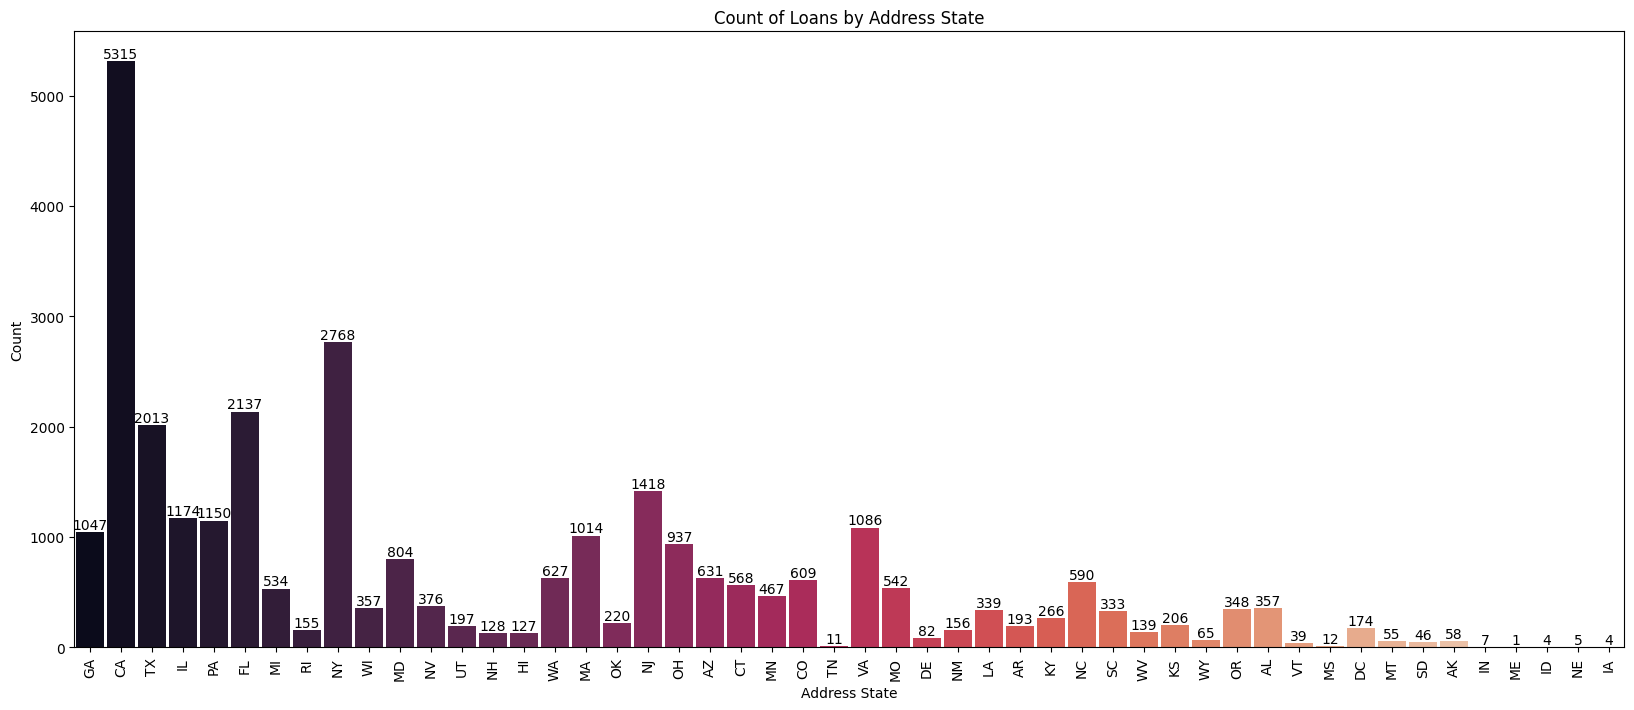

In [ ]:
plt.figure(figsize=(20,8))
ax = sns.countplot(x='address_state',data=df,palette="rocket",width=0.9)
plt.title("Count of Loans by Address State")
plt.xlabel("Address State")
plt.ylabel("Count")
plt.xticks(rotation=90)

for container in ax.containers:
    ax.bar_label(container)
plt.show()

Conclusion

The majority of borrowers fall under the RENT and MORTGAGE categories, indicating that most loan applicants do not fully own their homes. This suggests that individuals without full property ownership tend to rely more on loans.



In [ ]:
job_exp = df['emp_length'].value_counts()
job_exp

,count
emp_length,
10+ years,7054
2 years,3390
< 1 year,3249
3 years,3150
4 years,2681
5 years,2558
1 year,2438
6 years,1781
7 years,1400


/tmp/ipykernel_563/904843998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  z = sns.countplot(x='emp_length',data=df,palette="viridis")


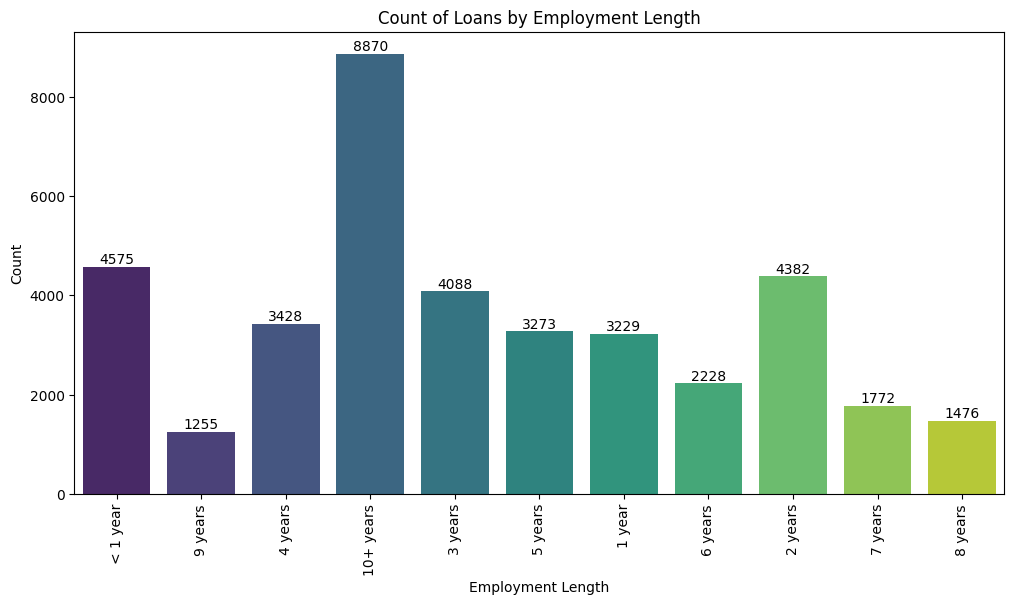

In [8]:
plt.figure(figsize=(12,6))
z = sns.countplot(x='emp_length',data=df,palette="viridis")
plt.title("Count of Loans by Employment Length")
plt.xlabel("Employment Length")
plt.ylabel("Count")
plt.xticks(rotation=90)

for container in z.containers:
    z.bar_label(container)

plt.show()

Conclusion (Count of Loans by Employment Length):

Borrowers with 10+ years of employment experience (7054) have the highest number of loans.

People with less than 1 year (3249) and 3 years (3150) of experience also apply for a significant number of loans.

Borrowers with mid-level experience (4–6 years) show moderate loan counts.

Employment lengths like 8 years (1185) and 9 years (1005) have relatively fewer loan applications.

/tmp/ipykernel_1887/723660332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.countplot(x='grade',data=df,palette="rocket")


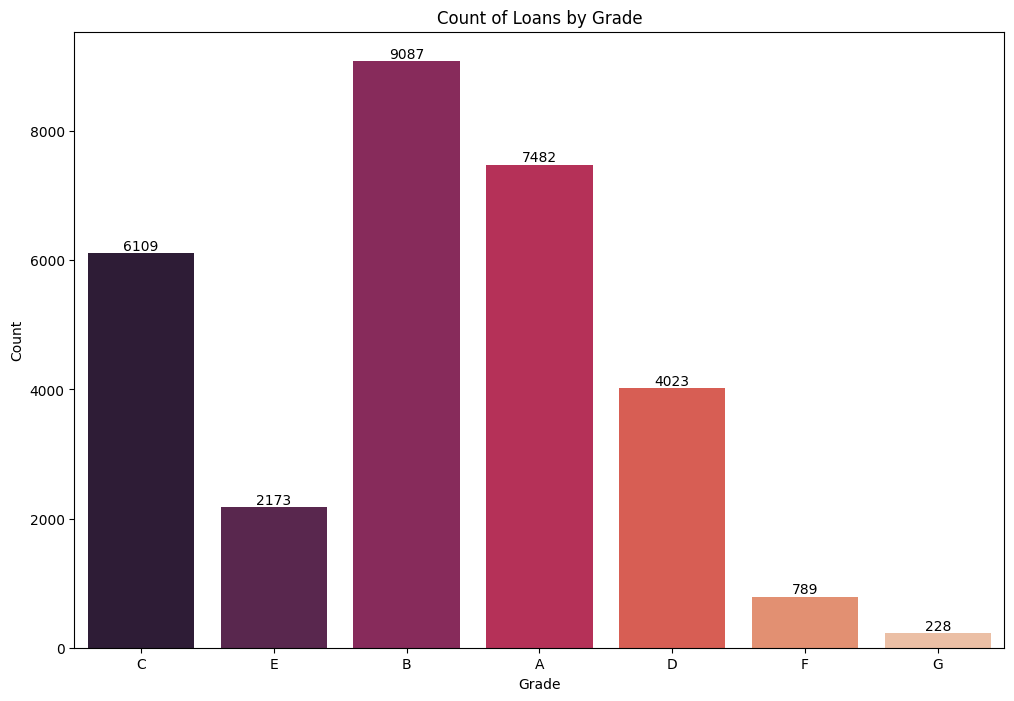

In [ ]:
plt.figure(figsize=(12,8))
a = sns.countplot(x='grade',data=df,palette="rocket")
plt.title("Count of Loans by Grade")
plt.xlabel("Grade")
plt.ylabel("Count")

for container in a.containers:
    a.bar_label(container)
plt.show()

Conclusion (Count of Loans by Grade):

Grade B loans are the highest (9087), meaning most borrowers fall in this credit category.

Grade A (7482) and Grade C (6109) also have a large number of loans.

Grade D (4023) and Grade E (2173) have fewer loans compared to higher grades.

Grade F (789) and Grade G (228) have the lowest number of loans, indicating very high-risk borrowers are less common.

In [ ]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

In [ ]:
home = df['home_ownership'].value_counts()
home



,count
home_ownership,
RENT,13908
MORTGAGE,13798
OWN,2115
OTHER,69
NONE,1


In [ ]:
df.drop(df[df['home_ownership'] == 'NONE'].index, inplace=True)

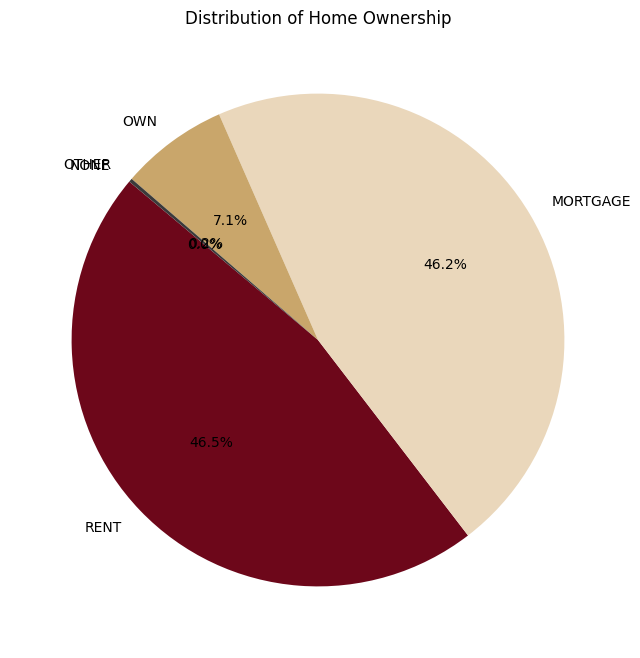

In [ ]:
plt.figure(figsize=(12,8))
colors = ['#6D071A','#EAD7BB','#C9A66B','#3A3A3A']
b = plt.pie(home,labels=home.index,autopct='%1.1f%%',startangle=140,colors=colors)
plt.title("Distribution of Home Ownership")
plt.show()

Conclusion (Distribution of Home Ownership):

The majority of borrowers either rent their homes (46.5%) or have a mortgage (46.2%).

A smaller portion of borrowers own their homes completely (7.1%).

Very few borrowers fall under other ownership categories.

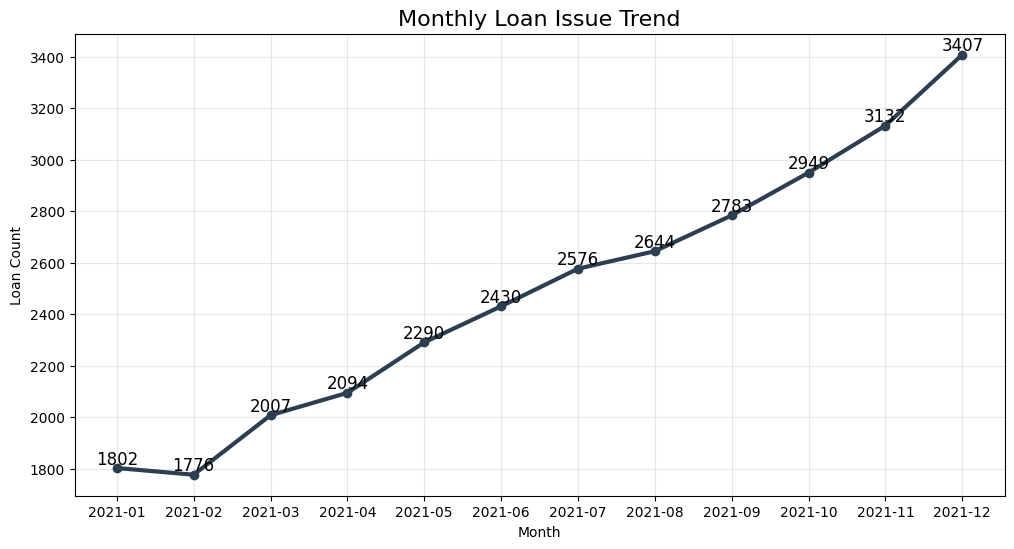

In [ ]:
df['issue_date'] = pd.to_datetime(df['issue_date'], dayfirst=True)
trend = df.groupby(df['issue_date'].dt.to_period('M')).size()
trend = trend.sort_index()

plt.figure(figsize=(12,6))

plt.plot(trend.index.astype(str), trend.values,
         marker='o', linewidth=3,color = '#2C3E50')

plt.grid(alpha=0.3)

plt.title("Monthly Loan Issue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Loan Count")

for i, v in enumerate(trend.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)



plt.show()

Conclusion (Monthly Loan Issue Trend):

The graph shows that loan issues increase steadily over the months.

At the beginning of the year, the number of issued loans is relatively low.

As the months progress, the number of loan applications gradually rises.

The highest number of loan issues occurs toward the end of the year (November–December).

In [ ]:
loan_status = df['loan_status'].value_counts()
loan_status

,count
loan_status,
Fully Paid,25174
Charged Off,3869
Current,847


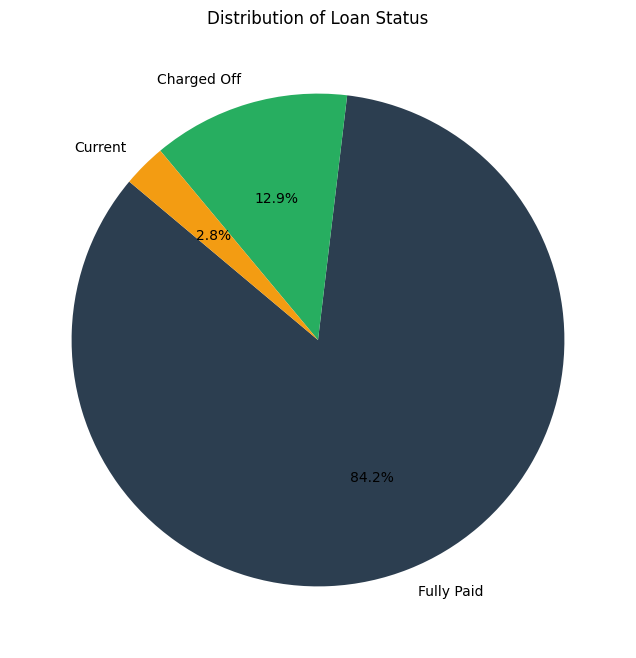

In [ ]:
plt.figure(figsize=(12,8))
colors = ['#2C3E50','#27AE60','#F39C12','#8E44AD']
plt.pie(loan_status,labels=loan_status.index,autopct='%1.1f%%',startangle=140,colors=colors)
plt.title("Distribution of Loan Status")
plt.show()

84.2% of the loans are Fully Paid, which shows that the majority of borrowers successfully repay their loans.

12.9% of the loans are Charged Off, meaning these loans have defaulted and were not repaid by the borrowers.

2.8% of the loans are Current, indicating that these loans are still in the repayment process.

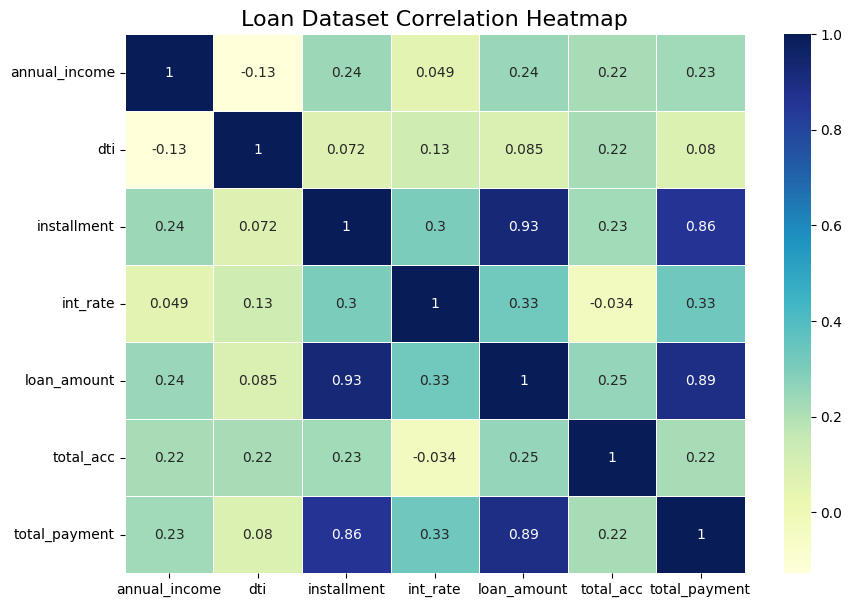

In [ ]:
num_cols = ['annual_income','dti','installment','int_rate',
            'loan_amount','total_acc','total_payment']

corr = df[num_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr,
            annot=True,
            cmap='YlGnBu',
            linewidths=0.5)

plt.title("Loan Dataset Correlation Heatmap",fontsize=16)

plt.show()

## Correlation Analysis

Correlation analysis is used to understand the relationship between numerical variables.

A correlation heatmap was created to identify how variables such as loan amount, installment, total payment, income, and interest rate are related.

Key insights observed from the correlation heatmap include:

- Loan amount has a strong positive relationship with installment.
- Loan amount also strongly correlates with total payment.
- Annual income shows a weak positive relationship with loan amount.
- Debt-to-income ratio shows very weak correlation with loan amount.

These relationships help us understand how different financial factors interact within the loan dataset.

T-Statistic: 12.756308945753547
P-Value: 3.5946949210394872e-37

Default Rates:
risk_group
High Risk    0.177624
Other        0.116777
Name: default, dtype: float64


/tmp/ipykernel_1887/2846231830.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='risk_group',y='default',data=df,palette="crest")


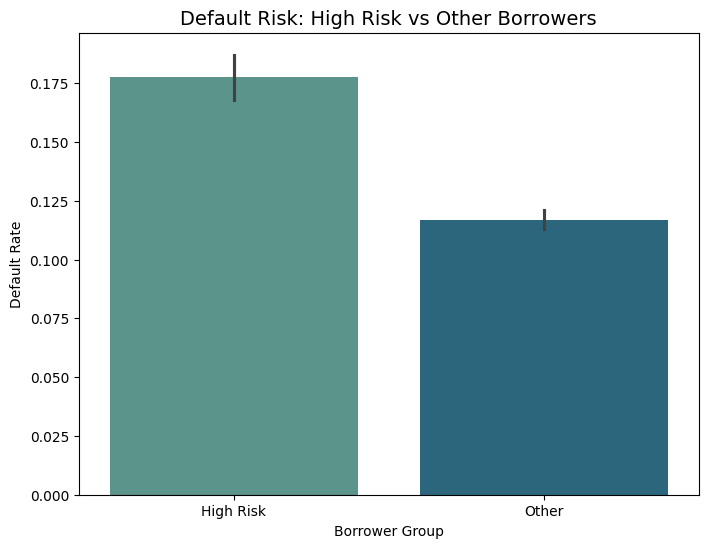


Result: Reject Null Hypothesis
Conclusion: RENT + Grade C/D/E borrowers have significantly higher default risk.


In [ ]:

from scipy.stats import ttest_ind


df['default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

df['risk_group'] = 'Other'

df.loc[(df['home_ownership'] == 'RENT') &(df['grade'].isin(['C','D','E'])), 'risk_group'] = 'High Risk'


high_risk = df[df['risk_group'] == 'High Risk']['default']
other = df[df['risk_group'] == 'Other']['default']

t_stat, p_value = ttest_ind(high_risk, other)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

default_rates = df.groupby('risk_group')['default'].mean()
print("\nDefault Rates:")
print(default_rates)


plt.figure(figsize=(8,6))

sns.barplot(x='risk_group',y='default',data=df,palette="crest")

plt.title("Default Risk: High Risk vs Other Borrowers", fontsize=14)
plt.ylabel("Default Rate")
plt.xlabel("Borrower Group")

plt.show()

if p_value < 0.05:
    print("\nResult: Reject Null Hypothesis")
    print("Conclusion: RENT + Grade C/D/E borrowers have significantly higher default risk.")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Conclusion: No significant difference in default risk.")

## Hypothesis Testing

To statistically test whether high-risk borrowers default more frequently than other borrowers, an Independent Two Sample T-Test was performed.

### Null Hypothesis (H₀)
There is no significant difference in default rates between high-risk borrowers and other borrowers.

### Alternative Hypothesis (H₁)
High-risk borrowers have a significantly different default rate compared to other borrowers.

The significance level used for the test is:

α = 0.05